# Which SEO Content Pages Should Be Reviewed First?

## Abstract

This capstone asks a practical ranking question: **which pseudonymized content pages should an SEO specialist review first when the available snapshot signals resemble pages with an observed decline?** I use a 30,000-row anonymized content dataset and define the observed outcome as `trend_direction == "down"`. A Random Forest is compared with Logistic Regression and a transparent Week-4 rule on the **same 75/25 client-grouped holdout**, while direct label-derived fields and identifiers are excluded from model features. On unseen clients, the Random Forest reaches **average precision 0.608 and ROC AUC 0.623**, compared with **AP 0.541 and ROC AUC 0.530** for the rule baseline; a naïve random-row split would overstate performance at about AP 0.806. The resulting score is therefore used only as **directional decision-support**: it prioritizes human review and attaches transparent reason codes, but it does not diagnose causes, guarantee future decline, or estimate the effect of an edit.


## 1. Question

**Decision supported:** Which pseudonymized content pages should an SEO specialist review first?

- **Unit of analysis:** one content page.
- **Output:** a ranking score and a review queue, not an autonomous edit.
- **Human action:** inspect high-ranked pages first, then decide whether a refresh, SERP/snippet review, content/intent review, or manual diagnosis is warranted.
- **Cost of a wrong call:** a false positive wastes reviewer time or encourages an unnecessary edit; a false negative delays review of a genuinely declining page. Because an unnecessary edit can also harm a page, the workflow keeps a human in the loop.

The value of ML here is not to replace judgment. It is to compress many weak page-level signals into a consistent triage order when review capacity is limited.


In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42

CANDIDATE_PATHS = [
    Path("content_refresh_anonymized.csv"),
    Path("content_refresh_anonymized(1).csv"),
    Path("data/raw/content_refresh_anonymized.csv"),
    Path("../data/raw/content_refresh_anonymized.csv"),
    Path("../../data/raw/content_refresh_anonymized.csv"),
    Path("/mnt/data/content_refresh_anonymized.csv"),
    Path("/mnt/data/content_refresh_anonymized(1).csv"),
]
data_path = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find content_refresh_anonymized.csv")

# Repo root = the parent of data/raw/<file>, resolved from wherever this notebook runs from
# (repo root itself, work/notebooks/, or a flat sandbox dir with the CSV alongside the notebook).
resolved = data_path.resolve()
REPO_ROOT = resolved.parents[2] if resolved.parent.name == "raw" else Path.cwd()

df = pd.read_csv(data_path)
y = (df["trend_direction"] == "down").astype(int)
groups = df["client_id"]
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns, {df['client_id'].nunique()} pseudonymous clients")
print(f"Observed down rate: {y.mean():.3f}")


Loaded 30,000 rows, 44 columns, 32 pseudonymous clients
Observed down rate: 0.542


## 2. Data

The public-safe release contains **30,000 rows, 44 columns, and 32 pseudonymous clients**. It includes page-level search, traffic, content, freshness, and engagement summaries. The release does not provide calendar dates; instead, it contains rolling windows such as 90-day aggregates and two adjacent 30-day impression windows.

### Data safety and exclusions

The observed target is `trend_direction == "down"`. I deliberately exclude:

- `trend_direction` — the target itself;
- `trend_pct` — the direct numeric source of the target;
- `impressions_last_30d` and `impressions_prev_30d` — together they reconstruct the trend calculation and therefore leak the answer;
- `content_id` and `client_id` — identifiers, not predictive features. `client_id` is used only to define the grouped split.

No client names, URLs, or raw/private queries are shown in the notebook, report, figures, or exported queue. Pseudonymized `content_id` is kept only so a reviewer can identify a row in the operational queue.


In [2]:
forbidden_features = {
    "content_id", "client_id", "trend_direction", "trend_pct",
    "impressions_last_30d", "impressions_prev_30d",
}
feature_columns = [c for c in df.columns if c not in forbidden_features]
X = df[feature_columns].copy()

# Demonstrate the leakage risk in the two recent impression windows.
prev = df["impressions_prev_30d"].replace(0, np.nan)
reconstructed = ((df["impressions_last_30d"] - df["impressions_prev_30d"]) / prev) * 100
valid = reconstructed.notna() & df["trend_pct"].notna() & np.isfinite(reconstructed)
leak_corr = float(np.corrcoef(reconstructed[valid], df.loc[valid, "trend_pct"])[0,1])
leak_mae = float(np.mean(np.abs(reconstructed[valid] - df.loc[valid, "trend_pct"])))

safety = pd.DataFrame({
    "check": ["Rows", "Pseudonymous clients", "Model features", "Forbidden fields in X", "Recent-window vs trend_pct correlation"],
    "result": [len(df), df["client_id"].nunique(), len(feature_columns), sorted(set(X.columns) & forbidden_features), round(leak_corr, 9)],
})
display(safety)
print(f"Trend reconstruction mean absolute error: {leak_mae:.4f}")
assert not (set(X.columns) & forbidden_features)


,check,result
0,Rows,30000
1,Pseudonymous clients,32
2,Model features,38
3,Forbidden fields in X,[]
4,Recent-window vs trend_pct correlation,1.0


Trend reconstruction mean absolute error: 0.0220


## 3. Methodology

This is a **binary ranking** task. The label is one sentence: **a page is positive when its observed `trend_direction` equals `down`**. The aim is to put more observed declines near the top of a finite human-review queue.

### Validation design

I use a reproducible **75/25 holdout grouped by `client_id`**. All pages from a client stay on one side of the split. This is stricter than a random row split because pages from the same client can share site-level patterns, content systems, or measurement conventions. The same held-out rows are used for the baseline and both learned models.

### Models

- **Transparent rule baseline:** combines a training-derived CTR gap within position buckets with 90-day impression opportunity.
- **Logistic Regression:** readable linear probability ranking.
- **Random Forest:** nonlinear comparison using the same non-leaking features.

Numeric preprocessing uses median imputation, missingness indicators, and standardization. Categorical preprocessing uses most-frequent imputation and one-hot encoding with safe handling of unseen categories. Random seed is fixed at **42**.


In [3]:
# Honest grouped split.
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
df_train, df_test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
train_clients = set(groups.iloc[train_idx]); test_clients = set(groups.iloc[test_idx])
assert train_clients.isdisjoint(test_clients)

numeric_features = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, min_samples_leaf=8, max_features="sqrt",
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
    ),
}
fitted = {}; model_scores = {}
for name, est in models.items():
    pipe = Pipeline([("preprocessor", clone(preprocessor)), ("model", est)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    model_scores[name] = pipe.predict_proba(X_test)[:,1]

# Week-4 transparent baseline, learned only from training references.
POSITION_BINS = [0, 3, 5, 10, 20, np.inf]
POSITION_LABELS = ["1-3", "4-5", "6-10", "11-20", "21+"]
btr = df_train[["impressions_90d", "ctr", "avg_position"]].copy()
bte = df_test[["impressions_90d", "ctr", "avg_position"]].copy()
btr["bucket"] = pd.cut(btr["avg_position"], POSITION_BINS, labels=POSITION_LABELS, include_lowest=True)
bte["bucket"] = pd.cut(bte["avg_position"], POSITION_BINS, labels=POSITION_LABELS, include_lowest=True)
med = btr.groupby("bucket", observed=False)["ctr"].median(); global_ctr=btr["ctr"].median()
tr_exp = btr["bucket"].map(med).astype(float).fillna(global_ctr)
te_exp = bte["bucket"].map(med).astype(float).fillna(global_ctr)
tr_gap=(tr_exp-btr["ctr"]).clip(lower=0); te_gap=(te_exp-bte["ctr"]).clip(lower=0)
def pct_against_train(train_values, test_values):
    ref=np.sort(np.asarray(train_values,dtype=float))
    return np.searchsorted(ref,np.asarray(test_values,dtype=float),side="right")/len(ref)
baseline_scores = 0.65*pct_against_train(tr_gap,te_gap) + 0.35*pct_against_train(btr["impressions_90d"],bte["impressions_90d"])

all_scores={"Week-4 baseline":baseline_scores, **model_scores}
def p_at_k(y_true,scores,k):
    idx=np.argsort(-np.asarray(scores))[:min(k,len(y_true))]
    return float(np.asarray(y_true)[idx].mean())
rows=[]
for name,s in all_scores.items():
    rows.append({"method":name,"average_precision":average_precision_score(y_test,s),"roc_auc":roc_auc_score(y_test,s),"precision_at_20":p_at_k(y_test,s,20),"precision_at_50":p_at_k(y_test,s,50)})
comparison=pd.DataFrame(rows).sort_values("average_precision",ascending=False).reset_index(drop=True)
print(f"Train/test rows: {len(train_idx):,} / {len(test_idx):,}")
print(f"Train/test clients: {len(train_clients)} / {len(test_clients)}; overlap={len(train_clients & test_clients)}")


Train/test rows: 22,885 / 7,115
Train/test clients: 24 / 8; overlap=0


## 4. Results — model vs. baseline

The Random Forest has the best overall held-out **average precision**, improving AP by about **0.067 absolute** over the transparent rule. Logistic Regression is close on AP and is notably stronger at precision@20, so the result is not “complexity always wins.” The key point is that all methods are judged on the same unseen clients.

The held-out positive rate is about **0.517**, so ranking metrics should be read relative to that base rate. The grouped validation is also materially weaker than a naïve random-row split: the Week-6 audit measured Random Forest AP around **0.806** under a random row split versus **0.608** when clients were held out. That gap is evidence that random-row validation would overstate transfer to unseen clients.


,method,average_precision,roc_auc,precision_at_20,precision_at_50
0,Random Forest,0.608,0.623,0.60,0.66
1,Logistic Regression,0.596,0.599,0.95,0.68
2,Week-4 baseline,0.541,0.530,0.70,0.74


Held-out positive/base rate: 0.517


,validation,average_precision,roc_auc
0,Random row split,0.807,0.793
1,Client-grouped split,0.608,0.623


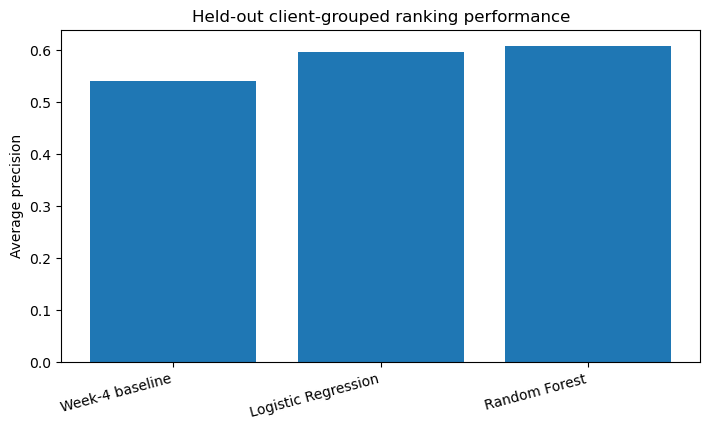

In [4]:
display(comparison.round(3))
print(f"Held-out positive/base rate: {y_test.mean():.3f}")

# Before/after split diagnostic from the same model design.
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X, y, test_size=.25, random_state=RANDOM_STATE, stratify=y)
rand_model = Pipeline([("preprocessor", clone(preprocessor)), ("model", RandomForestClassifier(
    n_estimators=250, min_samples_leaf=8, max_features="sqrt",
    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE))])
rand_model.fit(X_tr_r,y_tr_r)
rand_score=rand_model.predict_proba(X_te_r)[:,1]
split_audit=pd.DataFrame([
    ["Random row split", average_precision_score(y_te_r,rand_score), roc_auc_score(y_te_r,rand_score)],
    ["Client-grouped split", average_precision_score(y_test,model_scores["Random Forest"]), roc_auc_score(y_test,model_scores["Random Forest"])],
],columns=["validation","average_precision","roc_auc"])
display(split_audit.round(3))

# Figure 1: honest model-vs-baseline comparison.
figdir=REPO_ROOT/'work'/'figures'
figdir.mkdir(parents=True,exist_ok=True)
plot_df=comparison.set_index('method').loc[["Week-4 baseline","Logistic Regression","Random Forest"]]
plt.figure(figsize=(7.2,4.4))
plt.bar(plot_df.index,plot_df['average_precision'])
plt.ylabel('Average precision')
plt.title('Held-out client-grouped ranking performance')
plt.xticks(rotation=15,ha='right')
plt.tight_layout()
plt.savefig(figdir/'capstone_model_vs_baseline.png',dpi=160,bbox_inches='tight')
plt.show()


### What the model relies on

Permutation importance on the untouched grouped test split shows that the strongest predictive associations are led by **days with impressions**, **clicks in the last 30 days**, **average position**, and **90-day impressions**. These are associations with the ranking label, not causal levers. Shuffling a feature and seeing AP fall does not mean changing that feature would improve performance.


,feature,mean_AP_drop,std_AP_drop
18,days_with_impressions,0.0248,0.0028
20,clicks_last_30d,0.0208,0.0013
32,avg_position,0.0104,0.0013
10,impressions_90d,0.0080,0.0013
21,sessions_last_30d,0.0039,0.0008
37,position_tier,0.0036,0.0010
36,impression_tier,0.0025,0.0005
34,scroll_rate,0.0019,0.0005
23,sessions_prev_30d,0.0016,0.0007
31,ctr,0.0016,0.0005


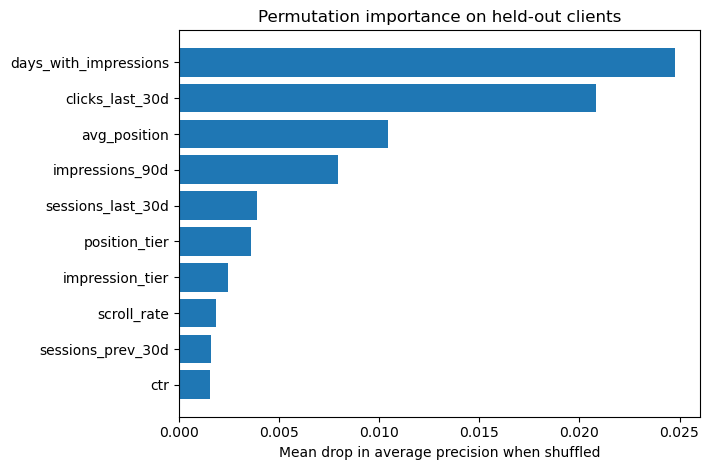

In [5]:
rf=fitted["Random Forest"]
perm=permutation_importance(rf,X_test,y_test,scoring='average_precision',n_repeats=5,random_state=RANDOM_STATE,n_jobs=-1)
importance=pd.DataFrame({'feature':X_test.columns,'mean_AP_drop':perm.importances_mean,'std_AP_drop':perm.importances_std}).sort_values('mean_AP_drop',ascending=False)
display(importance.head(10).round(4))
plt.figure(figsize=(7.2,4.8))
top=importance.head(10).sort_values('mean_AP_drop')
plt.barh(top['feature'],top['mean_AP_drop'])
plt.xlabel('Mean drop in average precision when shuffled')
plt.title('Permutation importance on held-out clients')
plt.tight_layout()
plt.savefig(figdir/'capstone_feature_importance.png',dpi=160,bbox_inches='tight')
plt.show()


## 5. Limitations and error analysis

This work **cannot** claim that the model predicts Google's algorithm, identifies the cause of a decline, guarantees a future decline, or estimates the lift/ROI of a content change. The label is an observed trend constructed from adjacent recent windows, and the validation is cross-client rather than a fully time-forward experiment.

The model also makes operationally meaningful mistakes. Some high-scored pages are not labeled down, while some observed declines receive very low scores. That is expected when direct trend-window fields are intentionally excluded: honest prediction must accept misses rather than leak the answer.

Other limitations include client mix, snapshot features that may omit seasonality/query changes/SERP changes, and the fact that the action archetypes are review suggestions rather than measured treatment effects.


In [6]:
rf_score=model_scores['Random Forest']
review=df_test[["content_id","content_type","impressions_90d","ctr","avg_position"]].copy()
review['actual_down']=y_test.to_numpy(); review['model_score']=rf_score
review['rank']=review['model_score'].rank(method='first',ascending=False).astype(int)
false_pos=review[(review['rank']<=50)&(review['actual_down']==0)].sort_values('rank').head(3)
missed=review[review['actual_down']==1].sort_values('model_score').head(3)
print('High-priority false positives:')
display(false_pos.round(4))
print('Observed declines with very low scores:')
display(missed.round(4))


High-priority false positives:


,content_id,content_type,impressions_90d,ctr,avg_position,actual_down,model_score,rank
22042,content_2ba626fea4d6,keyword article,360,0.00,7.2,0,0.9384,2
29456,content_b46c62b14582,keyword article,6240,0.13,31.8,0,0.9207,4
3669,content_5ce1a9d3e4d7,keyword article,8076,0.07,8.1,0,0.9072,8


Observed declines with very low scores:


,content_id,content_type,impressions_90d,ctr,avg_position,actual_down,model_score,rank
1864,content_16f38acf0f26,keyword article,2,0.00,50.0,1,0.1364,7066
1724,content_b72b06434946,keyword article,1061,0.19,41.0,1,0.1373,7064
27271,content_7bc32bc1df59,keyword article,1,0.00,0.0,1,0.1380,7063


## 6. Ranked recommendations

The model score answers **where to look first**. The reason codes then explain which visible, non-leaking signals make a review archetype plausible. They do not prove what is wrong.

For the top-200 held-out queue, the playbook uses four human-review archetypes:

1. **SERP/snippet review** — high model score plus CTR below the training-derived norm for the position bucket, especially in positions 4–20.
2. **Content/intent review** — high score plus weak engagement, prompting a reviewer to inspect whether the page still satisfies the task behind the query.
3. **Refresh review** — high score plus substantial time since last update; a reviewer must confirm actual factual staleness before editing.
4. **Manual diagnosis** — high score without a clean single archetype; investigate rather than forcing an action.

No action is autonomous. Reviewers should check search intent, SERP context, freshness, analytics quality, business constraints, and whether the proposed action actually fits the evidence.


In [7]:
# Training-only thresholds and reason codes, matching the Week-7 playbook.
q75_impressions=df_train['impressions_90d'].quantile(.75)
q25_engagement=df_train['engagement_rate'].quantile(.25)
score_q80=np.quantile(rf_score,.80); score_q95=np.quantile(rf_score,.95)
train_bucket=pd.cut(df_train['avg_position'],POSITION_BINS,labels=POSITION_LABELS,include_lowest=True)
ctr_med=df_train.assign(_b=train_bucket).groupby('_b',observed=False)['ctr'].median(); global_ctr=df_train['ctr'].median()
q=df_test[["content_id","content_type","main_intent","content_age_days","days_since_last_update","impressions_90d","ctr","avg_position","engagement_rate","ai_traffic_pct"]].copy()
q['model_score']=rf_score
q['position_bucket']=pd.cut(q['avg_position'],POSITION_BINS,labels=POSITION_LABELS,include_lowest=True)
q['position_ctr_median']=q['position_bucket'].map(ctr_med).astype(float).fillna(global_ctr)
q['ctr_below_position_norm']=q['ctr']<q['position_ctr_median']
q['value_tier']=pd.cut(q['impressions_90d'],bins=[-np.inf,df_train['impressions_90d'].quantile(.50),q75_impressions,np.inf],labels=['lower','medium','higher'])
def reasons(r):
    x=[]
    if r.model_score>=score_q80:x.append('HIGH_MODEL_SCORE')
    if r.days_since_last_update>=180:x.append('STALE_UPDATE')
    if r.impressions_90d>=q75_impressions:x.append('HIGH_IMPRESSION_OPPORTUNITY')
    if r.ctr_below_position_norm:x.append('CTR_BELOW_POSITION_NORM')
    if r.engagement_rate<=q25_engagement:x.append('WEAK_ENGAGEMENT')
    if 4<=r.avg_position<=20:x.append('STRIKING_DISTANCE')
    return '|'.join(x) if x else 'MODEL_SCORE_ONLY'
def action(r):
    if r.model_score>=score_q80 and r.days_since_last_update>=180:return 'REFRESH_REVIEW'
    if r.model_score>=score_q80 and r.ctr_below_position_norm and 4<=r.avg_position<=20:return 'SERP_SNIPPET_REVIEW'
    if r.model_score>=score_q80 and r.engagement_rate<=q25_engagement:return 'CONTENT_INTENT_REVIEW'
    if r.model_score>=score_q80:return 'MANUAL_DIAGNOSIS'
    return 'MONITOR'
q['reason_codes']=q.apply(reasons,axis=1); q['recommended_action']=q.apply(action,axis=1)
q['effort_band']=q['recommended_action'].map({'SERP_SNIPPET_REVIEW':'low','MONITOR':'low','CONTENT_INTENT_REVIEW':'medium','REFRESH_REVIEW':'medium-high','MANUAL_DIAGNOSIS':'medium'})
q['priority_band']=pd.cut(q['model_score'],bins=[-np.inf,score_q80,score_q95,np.inf],labels=['monitor','review','urgent_review'],include_lowest=True)
q=q.sort_values(['model_score','impressions_90d'],ascending=[False,False]).reset_index(drop=True); q.insert(0,'rank',np.arange(1,len(q)+1))
ranked_queue=q.head(200).copy()
action_mix=ranked_queue['recommended_action'].value_counts().rename_axis('action').reset_index(name='count')
display(action_mix)
display(ranked_queue[['rank','content_id','model_score','recommended_action','reason_codes','value_tier','effort_band']].head(12).round({'model_score':3}))


,action,count
0,SERP_SNIPPET_REVIEW,132
1,CONTENT_INTENT_REVIEW,66
2,MANUAL_DIAGNOSIS,1
3,REFRESH_REVIEW,1


,rank,content_id,model_score,recommended_action,reason_codes,value_tier,effort_band
0,1,content_e988c1699454,0.950,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|WEAK_ENGAGEMENT,medium,medium
1,2,content_2ba626fea4d6,0.938,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|CTR_BELOW_POSITION_NORM|WEAK_...,lower,low
2,3,content_9ac61c04930e,0.936,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|WEAK_ENGAGEMENT|STRIKING_DIST...,medium,medium
3,4,content_b46c62b14582,0.921,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|HIGH_IMPRESSION_OPPORTUNITY|W...,higher,medium
4,5,content_3395aba722a2,0.919,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|CTR_BELOW_POSITION_NORM|STRIK...,medium,low
5,6,content_0d7f4fecb391,0.919,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|WEAK_ENGAGEMENT,lower,medium
6,7,content_66458ac1b739,0.909,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|HIGH_IMPRESSION_OPPORTUNITY|W...,higher,medium
7,8,content_5ce1a9d3e4d7,0.907,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|HIGH_IMPRESSION_OPPORTUNITY|C...,higher,low
8,9,content_f55fd2d8ed04,0.907,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|WEAK_ENGAGEMENT,medium,medium
9,10,content_2dbab51b83c9,0.907,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|CTR_BELOW_POSITION_NORM|WEAK_...,lower,low


### Monitoring and retraining triggers

A deployed queue should be re-audited when evidence changes. Practical triggers from the Week-7 playbook are:

- grouped-validation AP drops by more than **0.10 absolute** from the current ~0.608 anchor;
- median model score shifts by more than **0.10 absolute**;
- a core numeric feature's new median moves outside the current held-out interquartile range;
- tracking definitions, the target construction, schema, or content taxonomy changes.

A broken pipeline should be fixed before retraining. Retraining is not a substitute for data-quality investigation.


## 7. Artifacts and reproducibility

The paper embeds only public-safe aggregate tables and figures. The operational CSV contains pseudonymized content IDs but no client identifiers, URLs, raw queries, target labels, `trend_pct`, or the two leaked recent impression windows.

### Fresh-clone rerun

From the repository root:

```bash
python -m venv .venv
source .venv/bin/activate          # Windows: .venv\Scripts\activate
pip install pandas numpy scikit-learn matplotlib jupyter nbconvert
jupyter nbconvert --to notebook --execute work/notebooks/capstone.ipynb \
  --output capstone.executed.ipynb --ExecutePreprocessor.timeout=600
```

Random seed: **42**. The analysis requires pandas, NumPy, scikit-learn, matplotlib, Jupyter, and nbconvert. The exact library version is printed during execution when available in the environment.


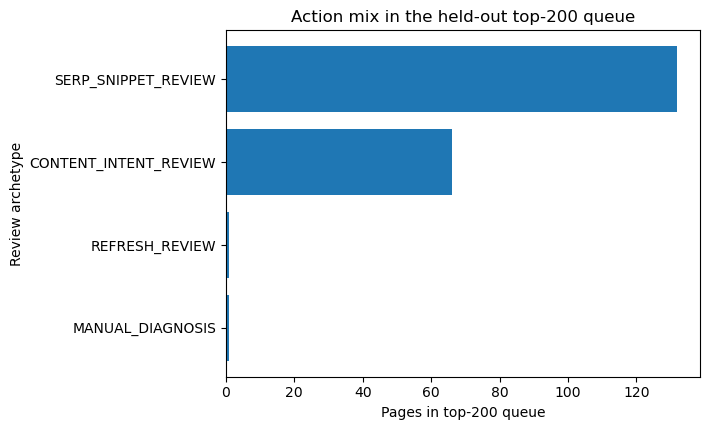

Saved: /private/tmp/claude-502/-Users-anel-murat-Desktop-intern-ml/cb07d837-0fa7-41b5-be63-ef2d4411f87e/scratchpad/repo_check/work/outputs/capstone_ranked_action_queue.csv
Saved: /private/tmp/claude-502/-Users-anel-murat-Desktop-intern-ml/cb07d837-0fa7-41b5-be63-ef2d4411f87e/scratchpad/repo_check/work/outputs/capstone_model_comparison.csv
Saved: /private/tmp/claude-502/-Users-anel-murat-Desktop-intern-ml/cb07d837-0fa7-41b5-be63-ef2d4411f87e/scratchpad/repo_check/work/outputs/capstone_metrics.json
Figures: ['capstone_action_mix.png', 'capstone_feature_importance.png', 'capstone_model_vs_baseline.png']


In [8]:
# Export public-safe artifacts.
outdir=REPO_ROOT/'work'/'outputs'; figdir=REPO_ROOT/'work'/'figures'; outdir.mkdir(parents=True,exist_ok=True); figdir.mkdir(parents=True,exist_ok=True)
export_cols=['rank','content_id','model_score','priority_band','recommended_action','reason_codes','value_tier','effort_band','content_type','main_intent','content_age_days','days_since_last_update','impressions_90d','ctr','avg_position','engagement_rate','ai_traffic_pct']
queue_export=ranked_queue[export_cols].copy()
assert 'client_id' not in queue_export.columns and 'trend_direction' not in queue_export.columns and 'trend_pct' not in queue_export.columns
queue_export.to_csv(outdir/'capstone_ranked_action_queue.csv',index=False)
comparison.to_csv(outdir/'capstone_model_comparison.csv',index=False)
metrics={
    'rows':int(len(df)),'clients':int(df['client_id'].nunique()),'overall_down_rate':float(y.mean()),
    'split':{'train_rows':int(len(train_idx)),'test_rows':int(len(test_idx)),'train_clients':len(train_clients),'test_clients':len(test_clients),'client_overlap':0,'test_base_rate':float(y_test.mean())},
    'comparison':comparison.to_dict(orient='records'),
    'random_row_audit':split_audit.to_dict(orient='records'),
    'top_features':importance.head(10).to_dict(orient='records'),
    'queue_action_counts':ranked_queue['recommended_action'].value_counts().to_dict(),
    'claim':'directional decision-support for human review; not causal or autonomous',
}
with open(outdir/'capstone_metrics.json','w') as f: json.dump(metrics,f,indent=2)

# Figure 3: action mix.
ac=ranked_queue['recommended_action'].value_counts().sort_values()
plt.figure(figsize=(7.2,4.4)); plt.barh(ac.index,ac.values); plt.xlabel('Pages in top-200 queue'); plt.ylabel('Review archetype'); plt.title('Action mix in the held-out top-200 queue'); plt.tight_layout(); plt.savefig(figdir/'capstone_action_mix.png',dpi=160,bbox_inches='tight'); plt.show()

print('Saved:', outdir/'capstone_ranked_action_queue.csv')
print('Saved:', outdir/'capstone_model_comparison.csv')
print('Saved:', outdir/'capstone_metrics.json')
print('Figures:', sorted(p.name for p in figdir.glob('capstone_*.png')))


## 8. Acknowledgments and data credit

This capstone uses the anonymized FlyRank internship content-refresh dataset supplied for the project. The workflow builds on the earlier baseline, model, validation-audit, and action-playbook assignments in the same repository. No private client names, URLs, or raw search queries are reproduced here.

## Final claim

> **On a held-out client-grouped split, the model provides a measured ranking signal for pages associated with an observed decline. I use that signal as directional decision-support to prioritize human review, then attach transparent non-leaking reason codes and review archetypes. The playbook does not automate edits, diagnose causes, or claim that a recommended intervention will improve performance.**


## Self-check

- [x] Every section is filled with reasoning and the code that backs the quantitative claims.
- [x] The notebook uses a client-grouped holdout with zero client overlap.
- [x] Model and baseline are evaluated on the same split.
- [x] The base rate is reported alongside ranking metrics.
- [x] `trend_direction`, `trend_pct`, recent trend-window impression fields, and IDs are excluded from model features.
- [x] No client names, URLs, or private queries are displayed or exported.
- [x] Claims use careful language: **observed, measured, directional, decision-support**.
- [x] Ranked recommendations require human review and include explicit no-causal/no-autonomy limits.
- [x] Public-safe figures, metrics, and a compact ranked queue are regenerated by the notebook.
- [ ] After adding the repository URL, commit this notebook under `work/notebooks/`, publish `docs/` with GitHub Pages, then place the exact live URL in `submission/paper_url.txt`.


## 5-Minute Demo Outline

A five-minute walkthrough of this capstone, in five beats.

**1. Question (30s)** — Out of thousands of pages, which one should a FlyRank editor review first when review capacity is limited? FlyRank's product already answers this with hand-written flags (health scores, quick-win tags); this capstone tests whether a trained model can do better on the same kind of decision, using only public-safe, pseudonymized signals.

**2. Method (1 min)** — A Random Forest and a Logistic Regression are compared against a transparent rule baseline (CTR gap + impression opportunity, standing in for a hand-written flag). All three are scored on the *same* held-out clients, using a **75/25 split grouped by `client_id`** — 24 training clients, 8 completely unseen test clients, zero overlap. Six fields that leak or identify are excluded before training: `trend_direction`, `trend_pct`, `impressions_last_30d`, `impressions_prev_30d`, `content_id`, `client_id`.

**3. One chart (1 min)** — `work/figures/capstone_model_vs_baseline.png`, shown below: average precision for the baseline, Logistic Regression, and Random Forest on the identical held-out clients.

![Model vs. baseline, held-out clients](../figures/capstone_model_vs_baseline.png)

**4. One honest result (1.5 min)** — On the client-grouped holdout, Random Forest reaches **AP 0.608 / ROC AUC 0.623** vs. **AP 0.541 / ROC AUC 0.530** for the rule baseline. The more important number: the *same* Random Forest scored under a naive random-row split reaches **AP 0.807** — about **0.20 AP higher**. That gap is the headline finding: random-row validation would have overstated how well this model generalizes to a brand-new client, which is exactly why the client-grouped design is the only result this paper reports as the operating number.

**5. One recommendation (1 min)** — Ship the Random Forest score as a **ranked human-review queue** (`work/outputs/capstone_ranked_action_queue.csv`), not an autonomous action. Attach the transparent reason codes already computed (e.g. `SERP_SNIPPET_REVIEW`, `CONTENT_INTENT_REVIEW`) so a reviewer sees *why* a page is ranked high, and require human sign-off before any edit, redirect, or deindex — the model flags where to look, it does not diagnose the cause or predict Google's algorithm.

## Shareable Cuts

**Social post (methodology + honest validation focus):**

> Built a page-review priority model on 30k anonymized SEO pages across 32 pseudonymous clients. First pass under a random row split looked great — AP 0.81. Then I re-ran it the honest way: a client-grouped holdout with zero client overlap between train and test. AP dropped to 0.61 (vs. 0.54 for a transparent rule baseline). That ~0.20 gap is the real finding — random splits flatter you when rows from the same client leak across train/test. Model = decision-support for human review only, not a causal or Google-algorithm claim. Paper: https://anelchik.github.io/anelsinternshipwork/

**Employer-facing summary (3 sentences):**

I built a Random Forest model that ranks anonymized web pages by how likely they are to need editorial review, using a 30,000-row pseudonymized SEO analytics dataset spanning 32 clients. Evaluated honestly on a client-grouped holdout with zero client overlap — rather than a random split, which would have overstated results by about 0.20 average precision — the model reached AP 0.608 versus 0.541 for a transparent rule-based baseline. The output is a ranked, reason-coded review queue intended strictly as decision-support for a human editor, not an automated or causal claim about page performance.